In [28]:
# %load_ext cuml.accel
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 设置字体为SimHei（黑体）
plt.rcParams['font.sans-serif'] = ['SimHei']
# 解决坐标轴负号显示问题
plt.rcParams['axes.unicode_minus'] = False

# 读取数据集

In [19]:
user_data = pd.read_csv('data/JD_IJCAI 19/user')
item_data = pd.read_csv('data/JD_IJCAI 19/item_info')
user_click_data = pd.read_csv('data/JD_IJCAI 19/user_click')
user_order_data = pd.read_csv('data/JD_IJCAI 19/user_order')

In [3]:
# 查看用户数据
user_data.head()

,user_id,gender,age_range
0,0,0,21~25
1,1,0,31~35
2,2,0,26~30
3,3,1,46~50
4,4,1,31~35


In [4]:
# 查看商品数据
item_data.head()

,item_id,cid1,cid2,cid3,cid1_name,cid2_name,cid3_name,brand_code,price,item_name,seg_name
0,100000002008,1315,1345,12015,服饰内衣,内衣,秋衣秋裤,12002.0,199.0,马克华菲保暖内衣 男士秋衣秋裤套装薄款棉质高弹棉毛衫秋冬男生线衣线裤 宝蓝圆领 L,内衣 高弹 男士 套装 秋衣 棉毛衫 宝蓝 线衣 薄款 秋裤 马克华菲 男生 保暖 棉质 线...
1,100000002009,6196,6227,6232,厨具,餐具,一次性用品,57642.0,19.9,乐扣乐扣 PE家用一次性保鲜膜 生鲜食品保鲜薄膜 LBM106*3 (3卷装)20cm*20M,保鲜膜 薄膜 20cm 生鲜 pe 保鲜 家用 20m 食品 卷装 一次性 乐扣乐扣
2,100000002011,6196,6227,6232,厨具,餐具,一次性用品,57642.0,18.9,乐扣乐扣 PE生鲜水果用一次性保鲜膜 厨房家用保鲜薄膜 LBM105*2(两卷装)30cm*20M,20m 保鲜 厨房 生鲜水果 pe 一次性 薄膜 30cm 乐扣乐扣 两卷装 家用 保鲜膜
3,100000002012,1315,1345,9744,服饰内衣,内衣,男式内裤,8439.0,199.0,花花公子男士内裤冰丝平角内裤男网眼透气弹力中腰四角裤男 4条装5370多色L,男士 弹力 多色 中腰 网眼 内裤 透气 冰丝 花花公子 四角裤 平角 4条装
4,100000002013,6196,11143,11153,厨具,茶具,茶具配件,18922.0,79.0,雅集智能恒温宝 加热保温茶杯垫 玻璃杯垫暖奶器茶具电热保温底座,雅集 茶杯垫 加热 电热 茶具 暖奶器 杯垫 保温 恒温宝 底座 玻璃 智能


In [5]:
# 查看点击数据
user_click_data.head()

,user_id,item_id,datetime,dt
0,0,1150551,2018-06-10 21:41:31,2018-06-10
1,0,11133236,2018-06-10 22:15:15,2018-06-10
2,0,6888601,2018-06-10 21:57:31,2018-06-10
3,0,5812383,2018-06-10 21:40:22,2018-06-10
4,0,4803330,2018-06-10 21:40:07,2018-06-10


In [6]:
# 查看订单数据
user_order_data.head()

,user_id,item_id,count,datetime,dt
0,0,4803330,2,2018-06-10 22:11:02,2018-06-10
1,0,6743054,1,2018-06-10 22:11:02,2018-06-10
2,0,4803334,2,2018-06-10 22:11:02,2018-06-10
3,0,6888601,1,2018-06-10 22:11:02,2018-06-10
4,0,2518073,2,2018-06-10 22:11:02,2018-06-10


# 数据基本信息


In [7]:
print('用户数据形状:', user_data.shape)
print('用户数据列:', user_data.columns.tolist())
print('商品数据形状:', item_data.shape)
print('商品数据列:', item_data.columns.tolist())
print('点击数据形状:', user_click_data.shape)
print('点击数据列:', user_click_data.columns.tolist())
print('订单数据形状:', user_order_data.shape)
print('订单数据列:', user_order_data.columns.tolist())

用户数据形状: (100000, 3)
用户数据列: ['user_id', 'gender', 'age_range']
商品数据形状: (6827234, 11)
商品数据列: ['item_id', 'cid1', 'cid2', 'cid3', 'cid1_name', 'cid2_name', 'cid3_name', 'brand_code', 'price', 'item_name', 'seg_name']
点击数据形状: (52983323, 4)
点击数据列: ['user_id', 'item_id', 'datetime', 'dt']
订单数据形状: (1458498, 5)
订单数据列: ['user_id', 'item_id', 'count', 'datetime', 'dt']


In [22]:
# 数据完整性验证
print('商品数据缺失值:')
print(item_data.isnull().sum())
print('缺失率:')
print(item_data.isnull().sum() / len(item_data) * 100)

商品数据缺失值:
item_id            0
cid1               0
cid2               0
cid3               0
cid1_name          0
cid2_name          0
cid3_name          0
brand_code     37427
price              0
item_name          1
seg_name      856682
dtype: int64
缺失率:
item_id        0.000000
cid1           0.000000
cid2           0.000000
cid3           0.000000
cid1_name      0.000000
cid2_name      0.000000
cid3_name      0.000000
brand_code     0.548202
price          0.000000
item_name      0.000015
seg_name      12.548010
dtype: float64


In [23]:
# 数据质量评估
print('用户数据基本统计:')
print(user_data.describe())
print('商品数据基本统计:')
print(item_data.describe())
print('点击数据基本统计:')
print(user_click_data.describe())
print('订单数据基本统计:')
print(user_order_data.describe())

用户数据基本统计:
             user_id         gender
count  100000.000000  100000.000000
mean    49999.500000       0.405000
std     28867.657797       0.490894
min         0.000000       0.000000
25%     24999.750000       0.000000
50%     49999.500000       0.000000
75%     74999.250000       1.000000
max     99999.000000       1.000000
商品数据基本统计:
            item_id          cid1          cid2          cid3    brand_code  \
count  6.827234e+06  6.827234e+06  6.827234e+06  6.827234e+06  6.789807e+06   
mean   2.154335e+10  4.862532e+03  6.390071e+03  8.372509e+03  1.205616e+05   
std    1.664265e+10  4.847746e+03  5.173076e+03  4.784336e+03  1.132162e+05   
min    1.000120e+05  1.730000e+02  1.810000e+02  4.340000e+02 -1.000000e+00   
25%    1.102751e+10  1.315000e+03  1.343000e+03  3.982000e+03  1.504200e+04   
50%    2.360775e+10  1.620000e+03  6.167000e+03  9.733000e+03  8.625600e+04   
75%    2.998756e+10  9.192000e+03  1.173100e+04  1.204700e+04  2.122610e+05   
max    2.001248e+11  1.7

# KNN插补price字段

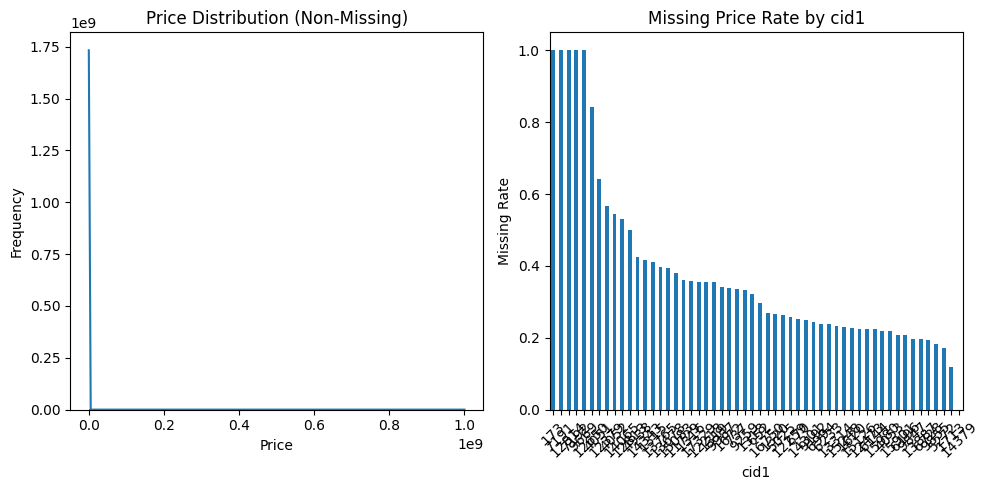

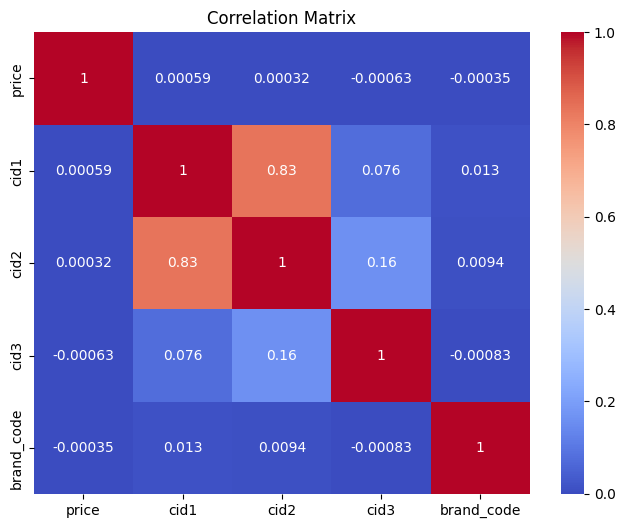

In [10]:
# 分析price分布和缺失模式
import matplotlib.pyplot as plt
import seaborn as sns

# price分布
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.histplot(item_data['price'].dropna(), bins=50, kde=True)
plt.title('Price Distribution (Non-Missing)')
plt.xlabel('Price')
plt.ylabel('Frequency')

# 缺失值与类别的关系
plt.subplot(1, 2, 2)
missing_by_cid1 = item_data.groupby('cid1')['price'].apply(lambda x: x.isnull().mean()).sort_values(ascending=False)
missing_by_cid1.plot(kind='bar')
plt.title('Missing Price Rate by cid1')
plt.xlabel('cid1')
plt.ylabel('Missing Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 相关性分析
numerical_cols = ['price']  # 如果有其他数值列，添加
categorical_cols = ['cid1', 'cid2', 'cid3', 'brand_code']
# 编码类别查看相关性
from sklearn.preprocessing import LabelEncoder
temp_data = item_data.copy()
for col in categorical_cols:
    le = LabelEncoder()
    temp_data[col] = le.fit_transform(temp_data[col].astype(str))
corr_matrix = temp_data[numerical_cols + categorical_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

填充缺失值，起初想用sklearn的knn，性能不行；
价格差距大，简单模型性能不好；

In [21]:
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# 假设 item_data 已经加载

features = ['cid1', 'cid2', 'cid3', 'brand_code']
target = 'price'

# --- 1. 数据预处理优化 --- 

# A. 处理异常值：剔除价格过高的样本
upper_limit = item_data[target].quantile(0.999)
print(f"剔除价格高于 {upper_limit} 的异常值...")
train_df = item_data[item_data[target] <= upper_limit].copy()

# B. 对数变换：解决长尾分布问题
train_df['log_price'] = np.log1p(train_df[target])

# C. 类别特征转换（增强版）
for col in features:
    # 处理缺失值
    train_df[col] = train_df[col].fillna('missing')
    
    # 动态计算低频阈值（数据量的0.1%）
    threshold = max(10, int(len(train_df) * 0.001))
    
    # 统计类别频率
    value_counts = train_df[col].value_counts()
    valid_categories = value_counts[value_counts >= threshold].index
    
    # 将低频类别替换为"other"
    train_df[col] = train_df[col].apply(lambda x: x if x in valid_categories else 'other')
    train_df[col] = train_df[col].astype('category')

# D. 划分训练集和验证集
X_train, X_val, y_train, y_val = train_test_split(
    train_df[features], 
    train_df['log_price'],
    test_size=0.2,
    random_state=42
)

# E. 构建LightGBM数据集
lgb_train = lgb.Dataset(X_train, y_train, categorical_feature=features)
lgb_val = lgb.Dataset(X_val, y_val, categorical_feature=features, reference=lgb_train)

# --- 2. 优化参数设置 --- 
params = {
    'boosting_type': 'gbdt',
    'objective': 'regression',
    'metric': 'rmse',
    'device': 'cpu',
    'n_jobs': -1,
    'force_col_wise': True,
    'learning_rate': 0.05,
    'num_leaves': 31,         # 与max_depth=5匹配
    'max_depth': 5,           # 限制树深度
    'min_data_in_leaf': 10,   # 适当减小
    'max_bin': 255,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'lambda_l1': 0.1,         # L1正则化
    'lambda_l2': 0.1,         # L2正则化
    'verbosity': -1           # 静默模式
}

# --- 3. 训练模型（带验证集监控） --- 
print("开始训练...")
model = lgb.train(
    params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_train, lgb_val],  # 关键：同时监控训练集和验证集
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),  # 基于验证集早停
        lgb.log_evaluation(100)
    ]
)
# --- 4. 模型评估（修复版） --- 
# A. 创建评估结果存储容器
eval_results = {}

# B. 训练模型时添加评估回调
model = lgb.train(
    params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_train, lgb_val],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(100),
        # 关键修复：使用回调函数存储评估结果
        lgb.record_evaluation(eval_results)
    ]
)

# C. 验证集性能评估（保持不变）
val_pred = model.predict(X_val, num_iteration=model.best_iteration)
val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
val_mae = mean_absolute_error(y_val, val_pred)
val_r2 = r2_score(y_val, val_pred)

print(f"\n验证集性能 (使用最佳迭代次数 {model.best_iteration}):")
print(f"RMSE: {val_rmse:.4f}")
print(f"MAE: {val_mae:.4f}")
print(f"R²: {val_r2:.4f}")

# D. 绘制学习曲线（修复版）
plt.figure(figsize=(10, 6))
# 从回调结果中获取评估数据
plt.plot(eval_results['training']['rmse'], label='Training RMSE')
plt.plot(eval_results['valid_1']['rmse'], label='Validation RMSE')
plt.xlabel('Boosting Rounds')
plt.ylabel('RMSE')
plt.title('Learning Curve')
plt.legend()
plt.grid(True)
plt.savefig('learning_curve.png')
plt.close()

# --- 5. 预测与反变换 --- 
# A. 准备预测数据
predict_df = item_data[item_data[target].isnull()][features].copy()

# B. 处理预测数据中的缺失值
for col in features:
    predict_df[col] = predict_df[col].fillna('missing')
    predict_df[col] = predict_df[col].astype('category')

# C. 预测
print("开始预测...")
pred_log_prices = model.predict(predict_df, num_iteration=model.best_iteration)

# D. 反变换并确保价格合理性
final_prices = np.expm1(pred_log_prices)
final_prices = np.maximum(final_prices, 0.01)  # 确保价格>0

# E. 填回原表
item_data.loc[item_data[target].isnull(), target] = final_prices

# --- 6. 保存模型和结果 --- 
model.save_model('price_prediction_model.txt')
print("模型已保存")

剔除价格高于 88800.0 的异常值...
开始训练...
Training until validation scores don't improve for 50 rounds
[100]	training's rmse: 1.13111	valid_1's rmse: 1.1321
[200]	training's rmse: 1.12769	valid_1's rmse: 1.12867
[300]	training's rmse: 1.12707	valid_1's rmse: 1.12806
[400]	training's rmse: 1.12682	valid_1's rmse: 1.1278
[500]	training's rmse: 1.1267	valid_1's rmse: 1.12769
[600]	training's rmse: 1.12662	valid_1's rmse: 1.12761
[700]	training's rmse: 1.12657	valid_1's rmse: 1.12757
[800]	training's rmse: 1.12653	valid_1's rmse: 1.12754
[900]	training's rmse: 1.12649	valid_1's rmse: 1.1275
[1000]	training's rmse: 1.12645	valid_1's rmse: 1.12747
Did not meet early stopping. Best iteration is:
[996]	training's rmse: 1.12645	valid_1's rmse: 1.12747
Training until validation scores don't improve for 50 rounds
[100]	training's rmse: 1.13111	valid_1's rmse: 1.1321
[200]	training's rmse: 1.12769	valid_1's rmse: 1.12867
[300]	training's rmse: 1.12707	valid_1's rmse: 1.12806
[400]	training's rmse: 1.12682	va

价格分布统计指标:
         指标             值
0        均值  1.316232e+03
1       中位数  2.049146e+02
2       标准差  3.955289e+05
3       最小值  1.000000e-02
4       最大值  1.000000e+09
5    25%分位数  7.990000e+01
6    75%分位数  4.990000e+02
7  99.9%分位数  6.500000e+04


C:\Users\lenovo\AppData\Local\Temp\ipykernel_32740\219262270.py:62: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missing from current font.
  plt.tight_layout()
C:\Users\lenovo\AppData\Local\Temp\ipykernel_32740\219262270.py:62: UserWarning: Glyph 26684 (\N{CJK UNIFIED IDEOGRAPH-683C}) missing from current font.
  plt.tight_layout()
C:\Users\lenovo\AppData\Local\Temp\ipykernel_32740\219262270.py:62: UserWarning: Glyph 39057 (\N{CJK UNIFIED IDEOGRAPH-9891}) missing from current font.
  plt.tight_layout()
C:\Users\lenovo\AppData\Local\Temp\ipykernel_32740\219262270.py:62: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from current font.
  plt.tight_layout()
C:\Users\lenovo\AppData\Local\Temp\ipykernel_32740\219262270.py:62: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from current font.
  plt.tight_layout()
C:\Users\lenovo\AppData\Local\Temp\ipykernel_32740\219262270.py:62: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) miss

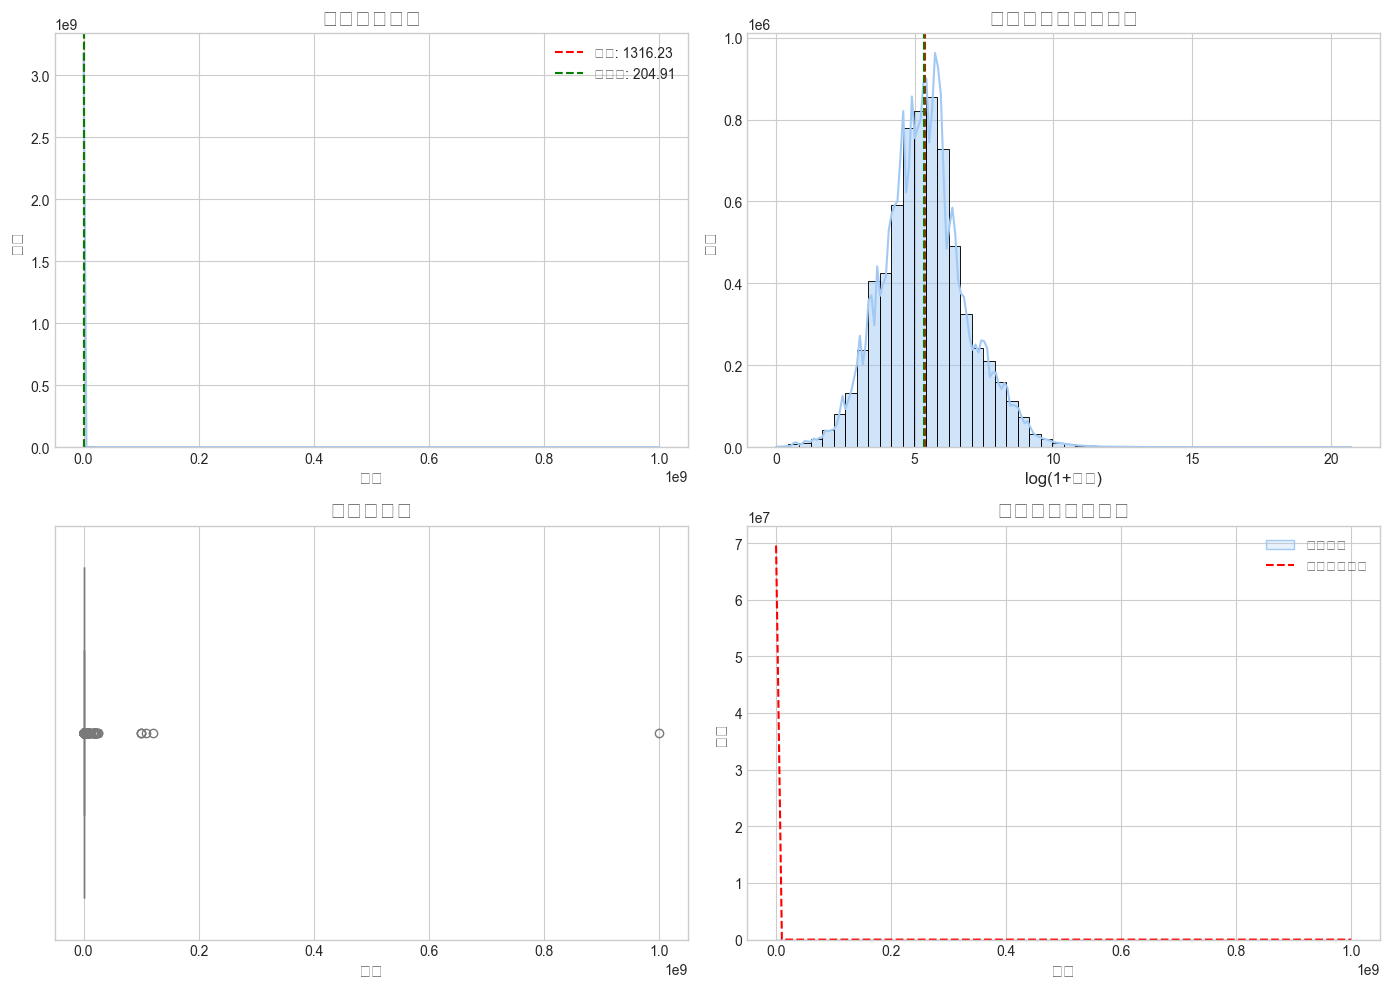

In [29]:


# 设置绘图风格
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("pastel")

# 1. 直方图与核密度估计
plt.figure(figsize=(14, 10))

# 原始价格分布
plt.subplot(2, 2, 1)
sns.histplot(item_data['price'], bins=50, kde=True)
plt.title('原始价格分布', fontsize=16)
plt.xlabel('价格', fontsize=12)
plt.ylabel('频数', fontsize=12)
plt.axvline(item_data['price'].mean(), color='r', linestyle='--', label=f'均值: {item_data["price"].mean():.2f}')
plt.axvline(item_data['price'].median(), color='g', linestyle='--', label=f'中位数: {item_data["price"].median():.2f}')
plt.legend()

# 对数变换后价格分布
plt.subplot(2, 2, 2)
sns.histplot(np.log1p(item_data['price']), bins=50, kde=True)
plt.title('对数变换后价格分布', fontsize=16)
plt.xlabel('log(1+价格)', fontsize=12)
plt.ylabel('频数', fontsize=12)
plt.axvline(np.log1p(item_data['price']).mean(), color='r', linestyle='--')
plt.axvline(np.log1p(item_data['price']).median(), color='g', linestyle='--')

# 2. 箱线图分析
plt.subplot(2, 2, 3)
sns.boxplot(x=item_data['price'])
plt.title('价格箱线图', fontsize=16)
plt.xlabel('价格', fontsize=12)

# 3. 价格分布统计指标
stats_df = pd.DataFrame({
    '指标': ['均值', '中位数', '标准差', '最小值', '最大值', '25%分位数', '75%分位数', '99.9%分位数'],
    '值': [
        item_data['price'].mean(),
        item_data['price'].median(),
        item_data['price'].std(),
        item_data['price'].min(),
        item_data['price'].max(),
        item_data['price'].quantile(0.25),
        item_data['price'].quantile(0.75),
        item_data['price'].quantile(0.999)
    ]
})
print("价格分布统计指标:")
print(stats_df)

# 4. 价格分布类型分析
plt.subplot(2, 2, 4)
sns.kdeplot(item_data['price'], label='实际分布', fill=True)
# 绘制正态分布参考线
x = np.linspace(item_data['price'].min(), item_data['price'].max(), 100)
y = (1/(item_data['price'].std() * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - item_data['price'].mean())/item_data['price'].std())**2)
plt.plot(x, y * len(item_data) * (x[1]-x[0]), 'r--', label='正态分布参考')
plt.title('价格分布类型分析', fontsize=16)
plt.xlabel('价格', fontsize=12)
plt.ylabel('密度', fontsize=12)
plt.legend()

plt.tight_layout()
plt.savefig('price_distribution_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [30]:
item_data.to_csv('data/JD_IJCAI 19/item_data_cleaned.csv', index=False, encoding='utf-8-sig')

# 数据入库